In [1]:
'''Here we compared the amitosis adaptation with amitosis load, with hope to find the reason why up to a certain ploidy, 
amitosis cannot lead to adaptation any more in Fisher's model. We thought this may be caused by amitosis load, in which 
the random segregation 

Setting: no pleiotropy. Population size N = 500, inital fitness = 0.5, STD =0.05, genomic mutation rate =0.01. 500 replicates.

We first calculated the mean phenotypic variance of each locus during adaptation under Ploidy = 46, 64 and 128, and with that
variance calculated the +x and -x pairs that can achieve a similar variance in monitoring amitosis load results. 

Here we compared the adaptation and amitosis load results.

Here using the corrected data collected using random.seed().


'''

"Here we compared the amitosis adaptation with amitosis load, with hope to find the reason why up to a certain ploidy, \namitosis cannot lead to adaptation any more in Fisher's model. We thought this may be caused by amitosis load, in which \nthe random segregation \n\nSetting: no pleiotropy. Population size N = 500, inital fitness = 0.5, STD =0.05, genomic mutation rate =0.01. 500 replicates.\n\nWe first calculated the mean phenotypic variance of each locus during adaptation under Ploidy = 46, 64 and 128, and with that\nvariance calculated the +x and -x pairs that can achieve a similar variance in monitoring amitosis load results. \n\nHere we compared the adaptation and amitosis load results.\n\nHere using the corrected data collected using random.seed().\n\n\n"

In [1]:
from __future__ import division
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [2]:
generation_list = []

for i in range(2002):
    generation_list.append(i)
    
print(len(generation_list))

2002


In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.mFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.mFit_Std,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.varFit_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.varFit_Std,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

In [4]:
def get_data2(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_var_mean = []
    total_var_std = []
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        var_mean = []
        var_std = []
       
        fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        var_mean.extend(list(pd.Series(f.PopVar_Mean,dtype=float)))
        var_std.extend(list(pd.Series(f.PopVar_STD,dtype=float)))
    
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_var_mean.append(var_mean)
        total_var_std.append(var_std)  
        
    return total_fit_mean, total_fit_std, total_var_mean, total_var_std

In [5]:
def read_file(data):
    with open(data, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [6]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

## P = 64_N =500_Rep =500

#### Amito load

In [7]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\3.1. No Pley_Monitor Amito Load_P =64_Amito Load vs Adaptation_N =500_Rep =500\Amito Load")

In [8]:
al2_list = ['Cor_AmitoLoad_NoPley_P64_N500_Dim10_IF1_MutScale000829_500Rep.csv']

In [9]:
al2 = get_data1(al2_list)

al2_fit_mean =al2[0][0]
al2_fit_std = al2[1][0]

#### Amitosis Adaptation

In [10]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\3.1. No Pley_Monitor Amito Load_P =64_Amito Load vs Adaptation_N =500_Rep =500\Adaptation")

In [11]:
ad2_list = ['Cor_NoPley_GMU001_Dim10_P64_Amito_Fit_N500_Fit05_SM005_Cor_500Rep.csv']

In [12]:
ad2 = get_data1(ad2_list)

ad2_fit_mean =ad2[0][0]
ad2_fit_std = ad2[1][0]

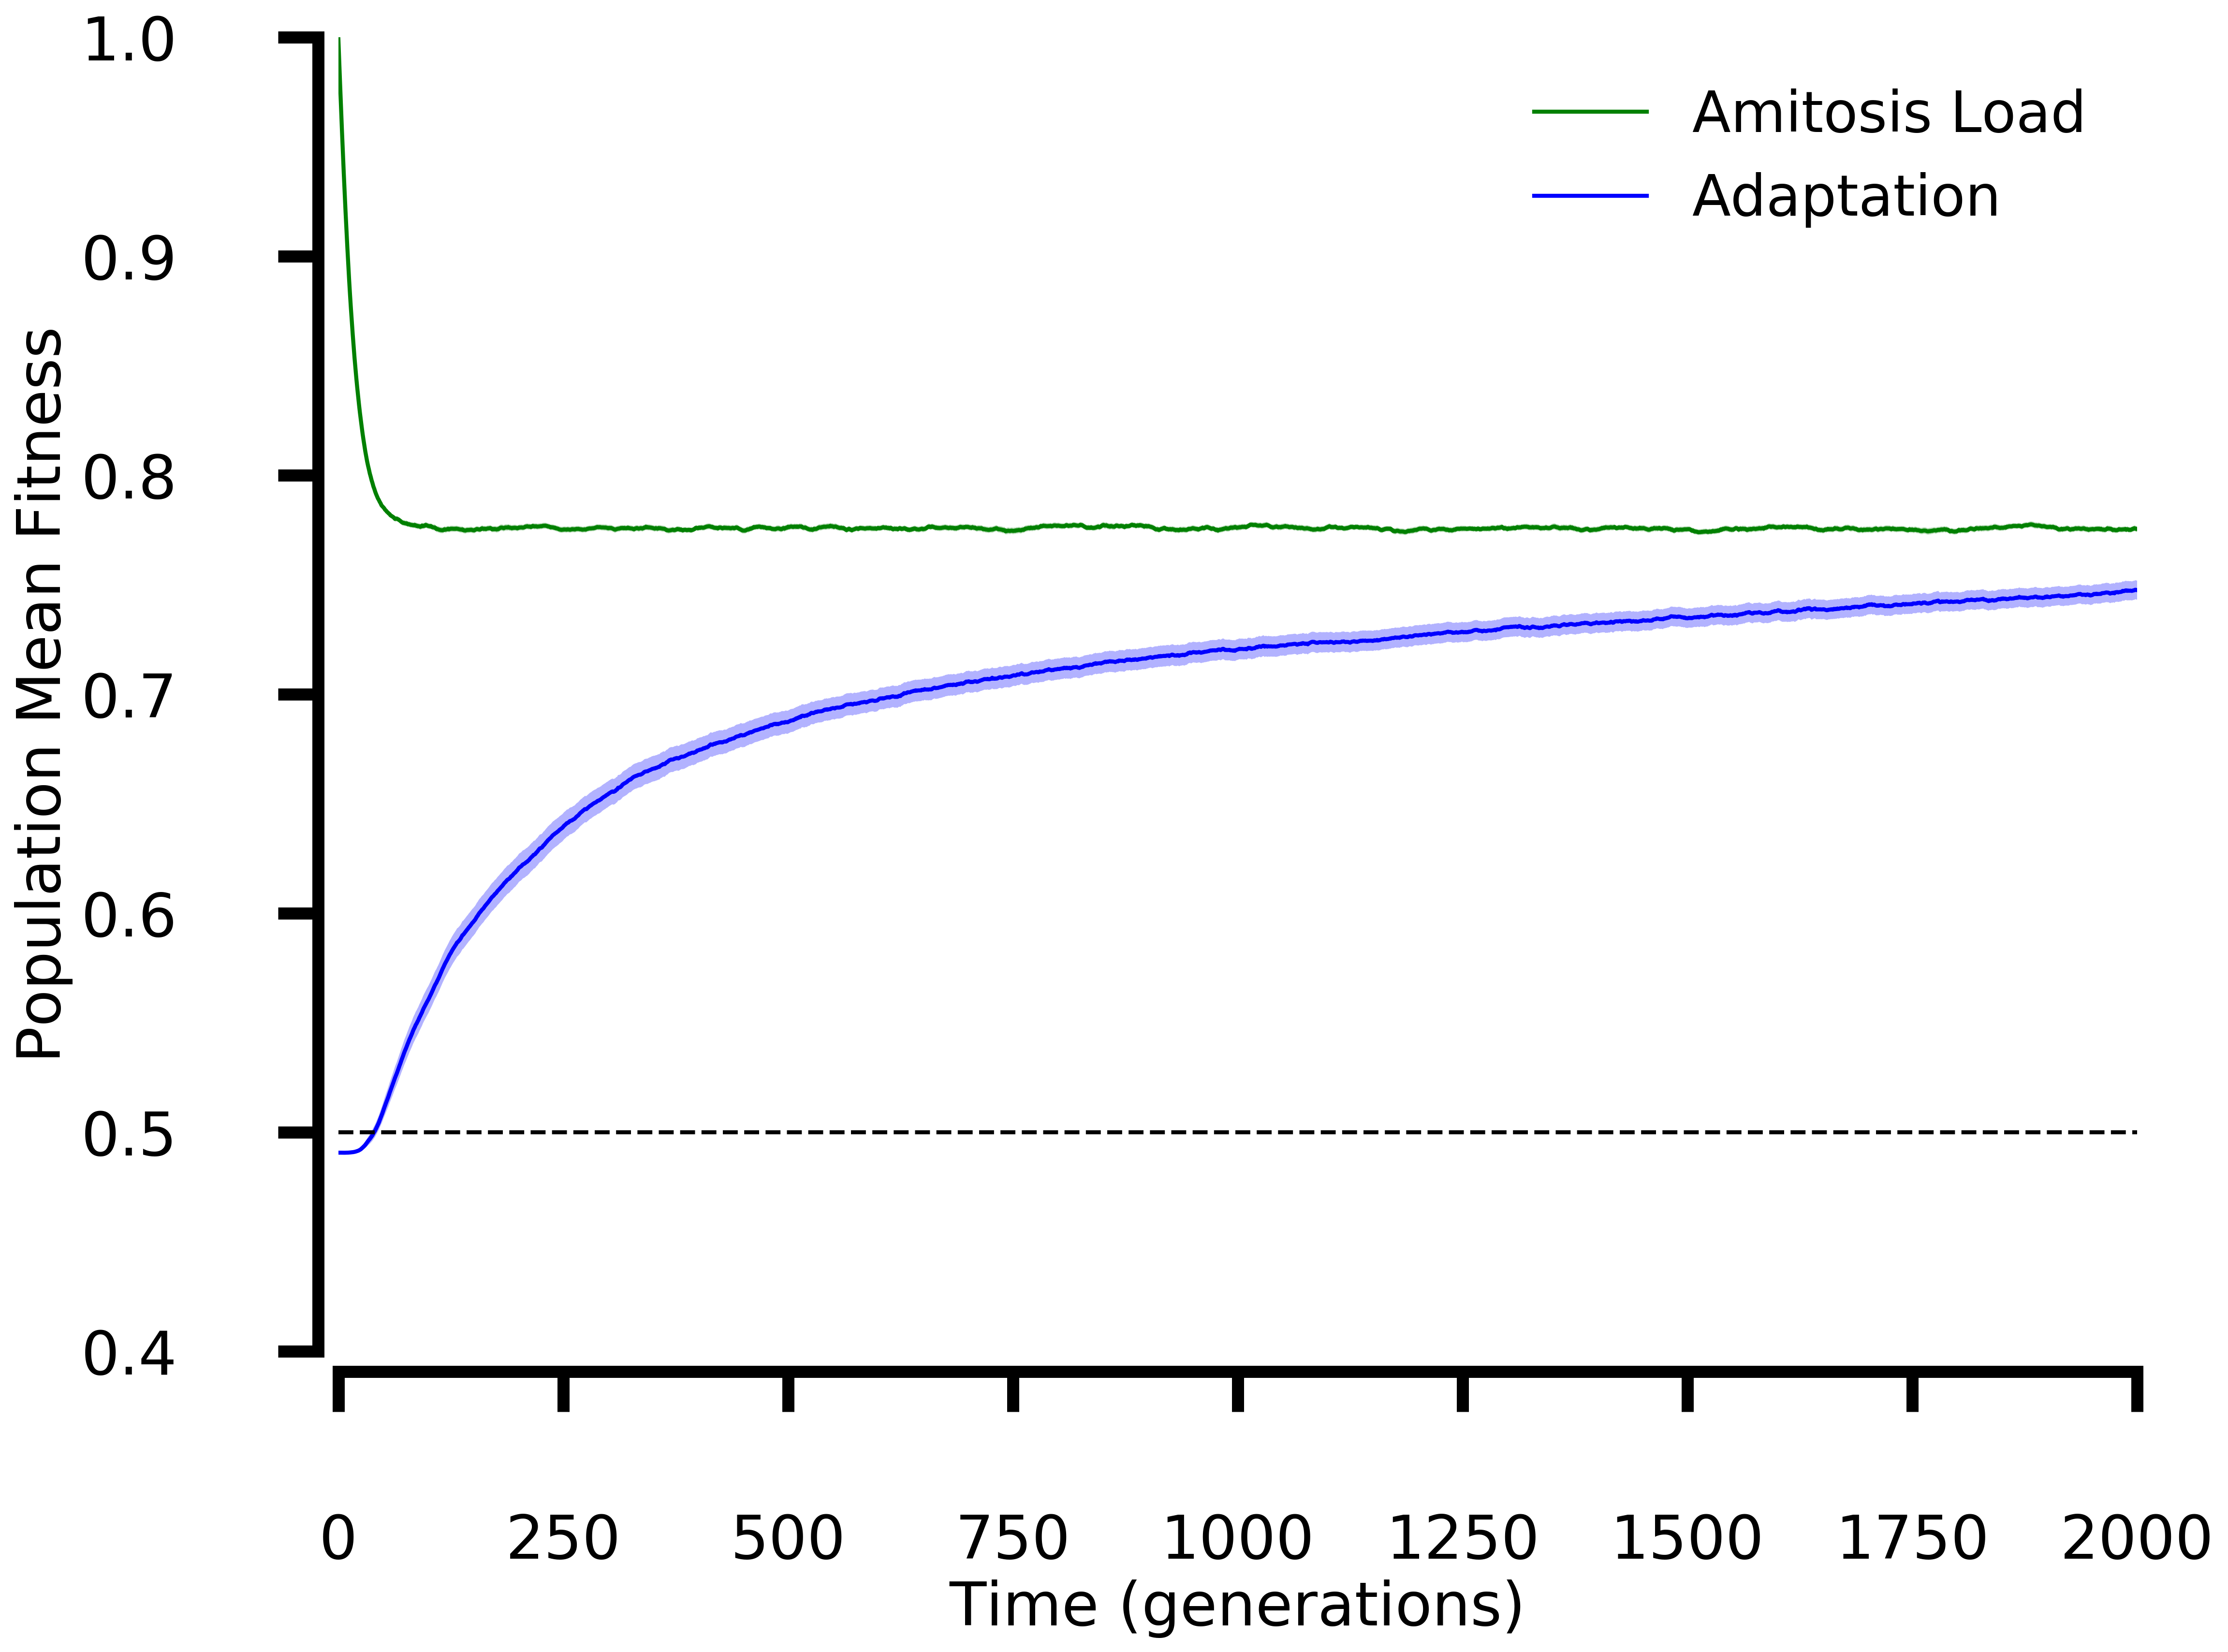

In [13]:
fig = plt.figure(figsize=(16, 12), dpi = 300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a = al2_fit_mean
error_a = list(1.97* np.array(al2_fit_std)/((500)**0.5))

b = ad2_fit_mean
error_b = list(1.97* np.array(ad2_fit_std)/((500)**0.5))


# ax.set_title('FGM_No Pley_Adapt Vs Amito Load_P =64_N =500_Rep =500_Corrected', fontsize =35)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Population Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'g', label = 'Amitosis Load',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.3, facecolor='g')

ax.plot(t,b,'b', label = 'Adaptation', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.3, facecolor='b')





plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

# extraticks=[0.45, 0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.4, 1)

plt.legend(loc='upper right', frameon=False, prop={'size':28})

# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

## P = 128_N =500_Rep =500

#### Amito load

In [14]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\4.1. No Pley_Monitor Amito Load_P =128_Amito Load vs Adaptation_N =500_Rep =500\Amito Load")

In [15]:
al3_list = ['Cor_AmitoLoad_NoPley_P128_N500_Dim10_IF1_MutScale000636_500Rep.csv']

In [16]:
al3 = get_data1(al3_list)

al3_fit_mean =al3[0][0]
al3_fit_std = al3[1][0]

#### Adaptation

In [17]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20181220_Test of FGM_5_Monitor Amito Load\Data\4.1. No Pley_Monitor Amito Load_P =128_Amito Load vs Adaptation_N =500_Rep =500\Adaptation")

In [18]:
ad3_list = ['Cor_NoPley_GMU001_Dim10_P128_Amito_Fit_N500_Fit05_SM005_Cor_500Rep.csv']

In [19]:
ad3 = get_data1(ad3_list)

ad3_fit_mean =ad3[0][0]
ad3_fit_std = ad3[1][0]

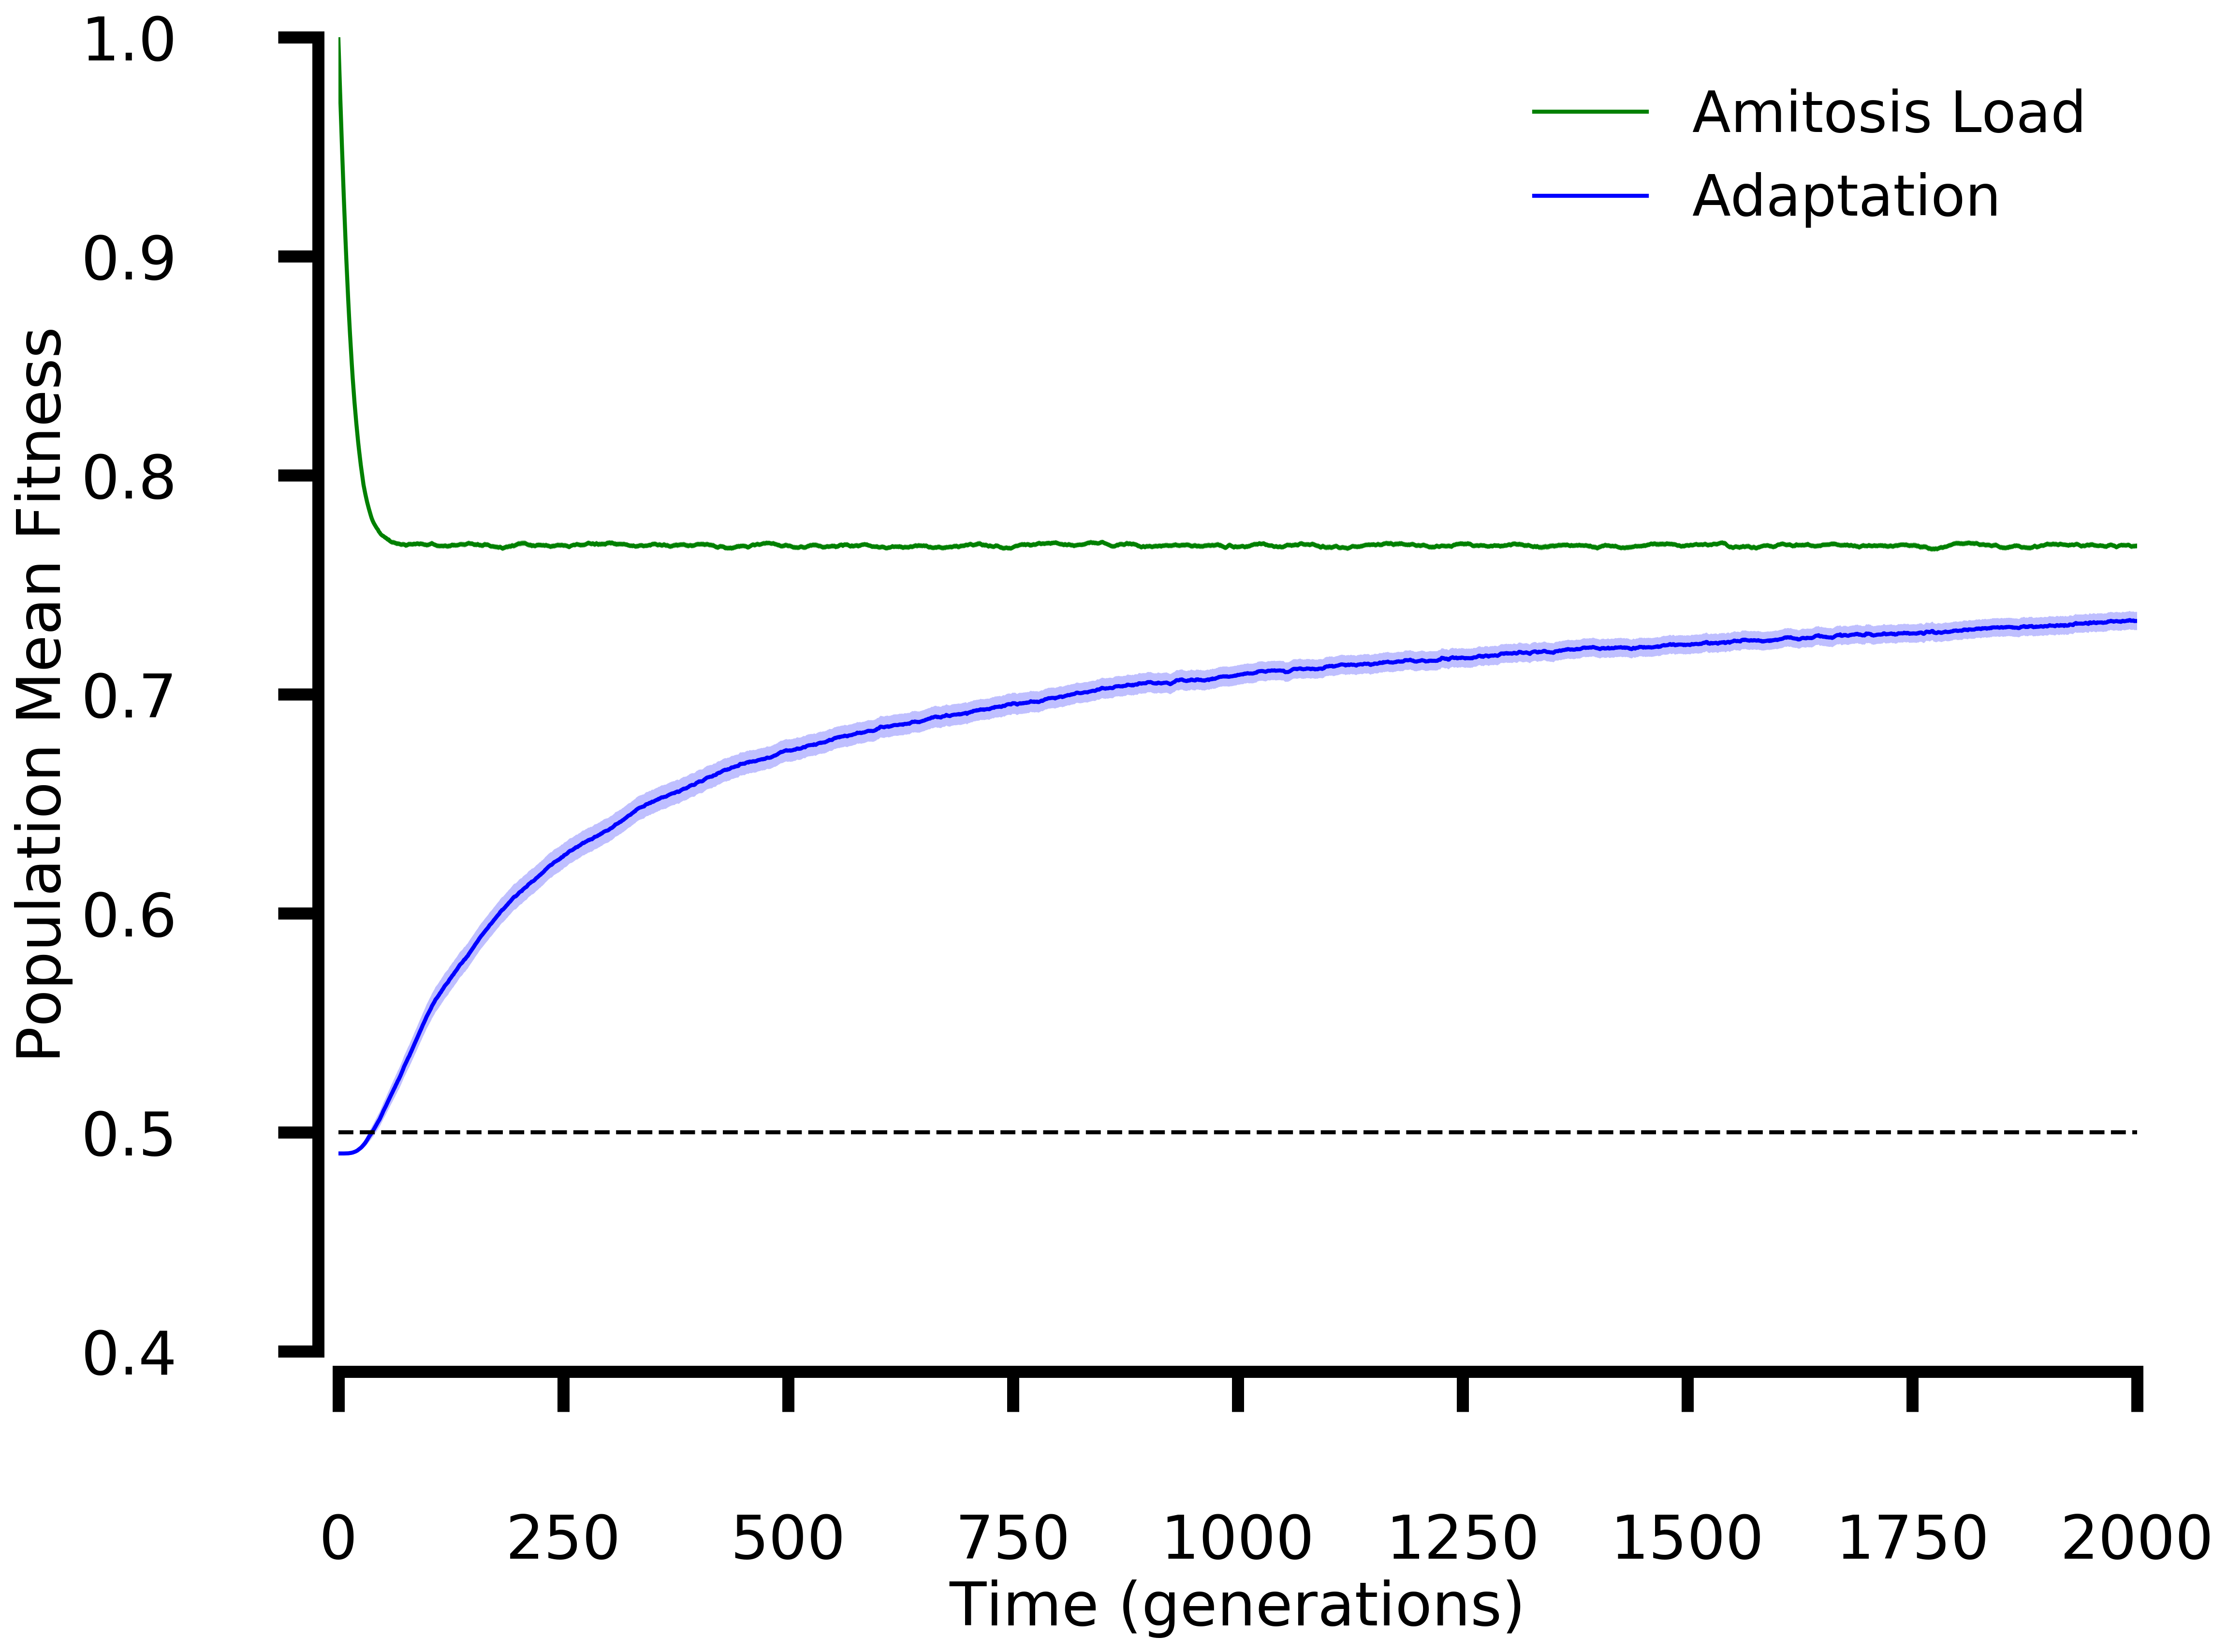

In [20]:
fig = plt.figure(figsize=(16, 12), dpi = 300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,2000)

t = generation_list

a = al3_fit_mean
error_a = list(1.97* np.array(al3_fit_std)/((500)**0.5))

b = ad3_fit_mean
error_b = list(1.97* np.array(ad3_fit_std)/((500)**0.5))


# ax.set_title('FGM_No Pley_Adapt Vs Amito Load_P =128_N =500_Rep =500_Corrected', fontsize =35)
ax.set_xlabel('Time (generations)', fontsize =30)
ax.set_ylabel('Population Mean Fitness', fontsize =30)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a,'g', label = 'Amitosis Load',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.45, facecolor='g')

ax.plot(t,b,'b', label = 'Adaptation', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.25, facecolor='b')



plt.axhline(y=0.5, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =25)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

# extraticks=[0.45, 0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.4, 1)

plt.legend(loc='upper right', frameon=False, prop={'size':28})

# plt.show()
# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

In [37]:
9.025069963609954e-05**0.5

0.009500036822881244